# Final Project Notebook

Use the follow cells prompts to complete the final project for the course. Everything you need should be present in this notebook or previous notebooks we've used in class. You can work together as needed. 

 - You will need to name your own dataset and use that name throughout
 - There are sections where you need to make changes the code and insert new code this will be noted in the code provided
 - You may get frustrated along the way, this is totally normal, just remember even small changes to the code make a huge difference. 

## Question Fork the Repository
i. Include a screenshot of the forked repo in your GitHub account

To fork the repository:
1. Go to https://github.com/NovaVolunteer/ds1001_final
2. Click the "Fork" button in the top right corner
3. The repo will be forked to your GitHub account
4. Take a screenshot of your forked repository

### You should now be able to open your cloned repo in google collab, use the code below. 

### It's very helpful to have the variable inspector open while you go through this process. To do so go to tools>command palette>show variable inspector

### It's also helpful to open up the folder tree on the left menu bar. Just click on the folder icon and then the ds1001_final folder. The data is located in the data folder in the processed sub-folder. 

In [58]:
!git clone "https://github.com/username/repository.git"
# This script clones a GitHub repository using Git command line tool. 
# Insert the path to your desired repository in place of the URL.

Cloning into 'repository'...
remote: Repository not found.
fatal: repository 'https://github.com/username/repository.git/' not found


## Systems

In [59]:
# Activate the finalproj environment
!source ds1001_final/ds1001_final/finalproj/bin/activate

/bin/bash: line 1: ds1001_final/ds1001_final/finalproj/bin/activate: No such file or directory


In [60]:
### You can use this command to list all the packages in your environment
!pip list

Package                   Version
------------------------- -----------
anyio                     4.12.1
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.2.0
attrs                     25.4.0
Automat                   25.4.16
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
certifi                   2026.2.25
cffi                      2.0.0
charset-normalizer        3.4.5
colorama                  0.4.6
comm                      0.2.3
constantly                23.10.4
contourpy                 1.3.3
cryptography              47.0.0
cssselect                 1.4.0
cycler                    0.12.1
debugpy                   1.8.20
decorator                 5.2.1
defusedxml                0.7.1
executing                 2.2.1
fairlearn                 0.13.0
fastjsonschema            2.21.2
filelock                  3.29.0
fonttools   

In [61]:
!pip install "XX"

#You'll likely need to install the fairlearn packages, if not already installed.
#Are there additional packages to install? (Cross check with the list above to 
# ensure all packages are installed)

In [62]:
# Use the notebook kernel environment
import sys
print("Python executable:", sys.executable)
print("Python version:", sys.version)


Python executable: /usr/local/python/3.12.1/bin/python
Python version: 3.12.1 (main, Mar 11 2026, 12:17:56) [GCC 13.3.0]


In [63]:
import sys
!{sys.executable} -m pip install pandas numpy seaborn matplotlib scikit-learn fairlearn


### Check !pip list again to confirm installations

In [64]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import fairlearn.metrics
from fairlearn.metrics import MetricFrame
from fairlearn.metrics import count, true_positive_rate, false_positive_rate, selection_rate, demographic_parity_ratio


## Design: Data prep and exploration 

In [65]:
# How many rows are in the dataframe? How many columns?
# bank_data = pd.read_csv('../data/processed/bank_final.csv')

# How many rows are in the dataframe? How many columns?
print(f"Number of rows: {bank_data.shape[0]}")
print(f"Number of columns: {bank_data.shape[1]}")
print(f"\nDataFrame shape: {bank_data.shape}")
print(f"\nFirst few rows:")
print(bank_data.head())
print(f"\nColumn names:")
print(bank_data.columns.tolist())

Number of rows: 43628
Number of columns: 29

DataFrame shape: (43628, 29)

First few rows:
        age   balance  duration  contactndays  signed up  job_blue-collar  \
0  0.324675  0.073384  0.046767      0.000000        0.0            False   
1  0.727273  0.123091  0.051444      0.208716        0.0            False   
2  0.194805  0.076190  0.078081      0.000000        0.0            False   
3  0.246753  0.081283  0.052460      0.000000        0.0             True   
4  0.155844  0.072812  0.014030      0.000000        0.0            False   

   job_entrepreneur  job_housemaid  job_management  job_retired  ...  \
0             False          False           False        False  ...   
1             False          False           False         True  ...   
2             False          False            True        False  ...   
3             False          False           False        False  ...   
4             False          False           False        False  ...   

   education_

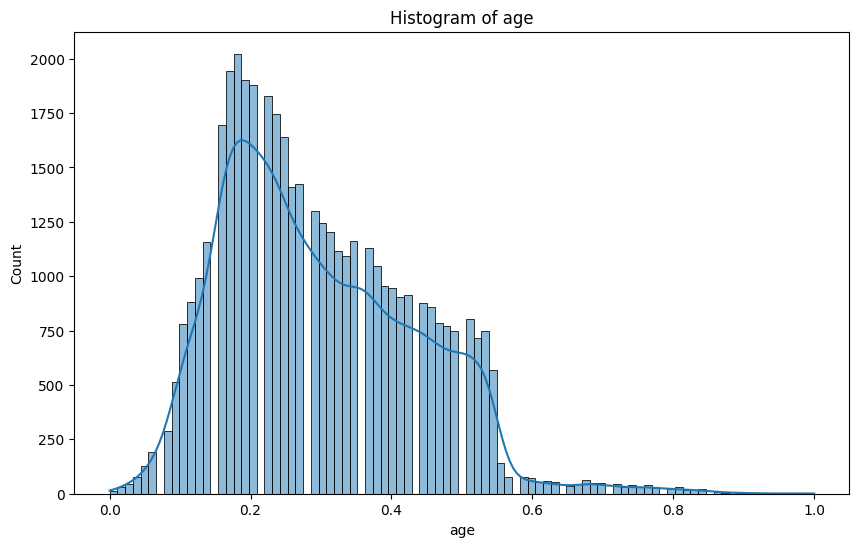

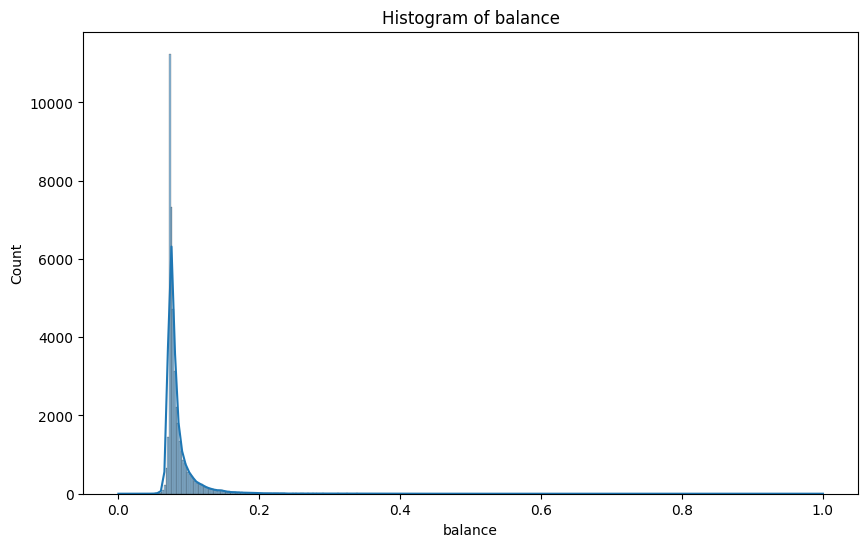

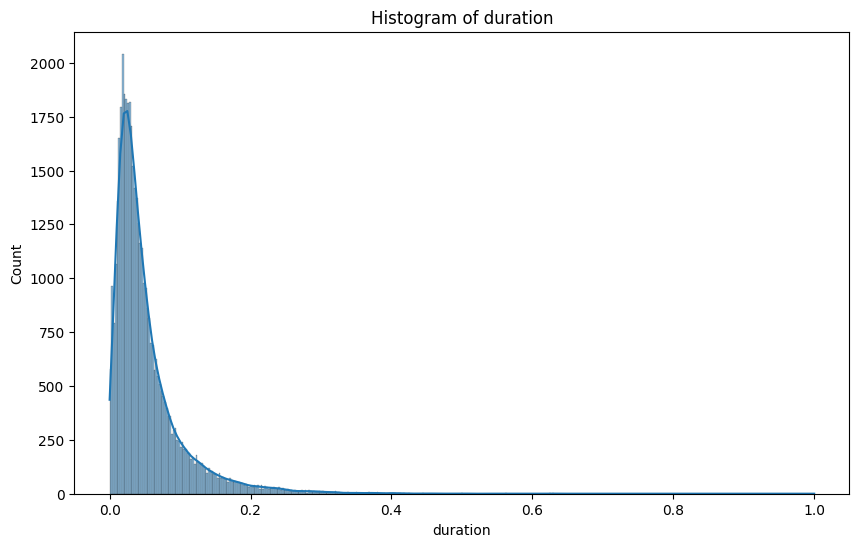

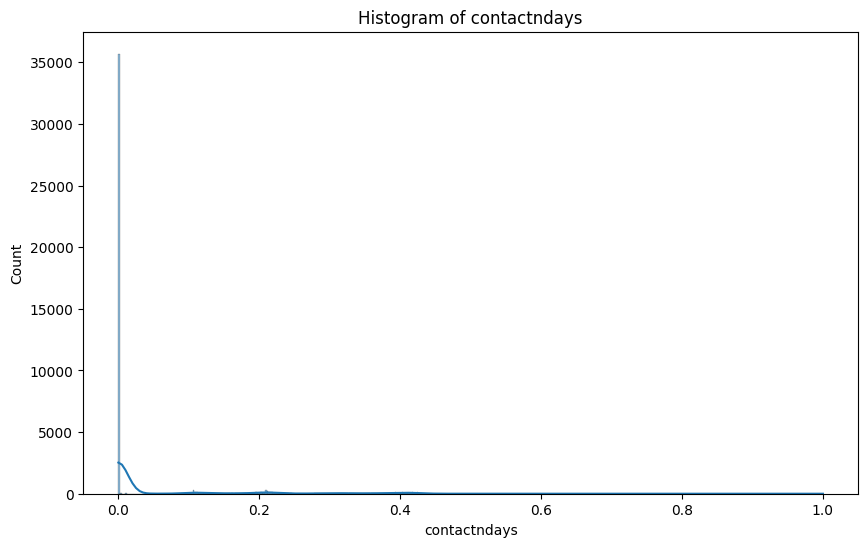

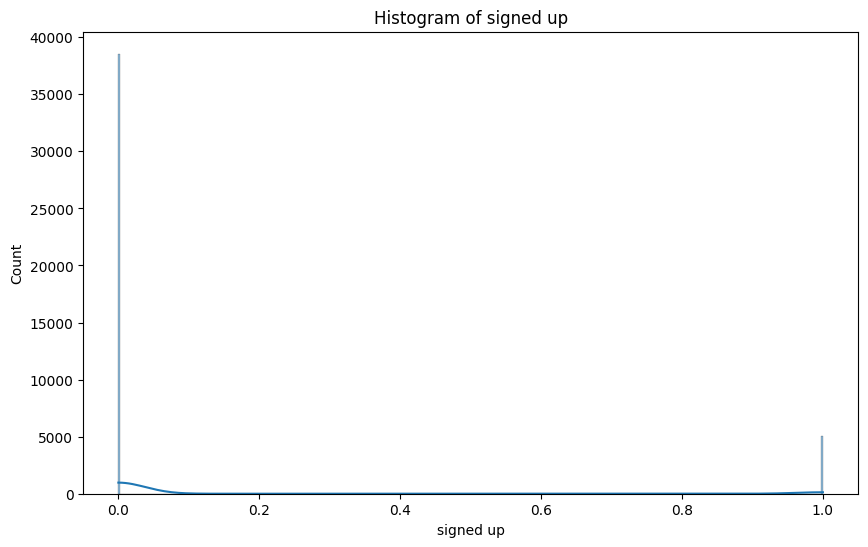

In [66]:
# Explore the variables a bit more, create histograms for the numerics values and bar charts for the categorical.
# Histograms for numeric variables
numeric_columns = bank_data.select_dtypes(include=['number']).columns
for col in numeric_columns: 
    plt.figure(figsize=(10, 6))
    sns.histplot(bank_data[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.show()  




In [67]:
# Bar charts for categorical variables
categorical_columns = bank_data.select_dtypes(include=['object', 'category']).columns
for col in categorical_columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=bank_data[col])
    plt.title(f'Bar Chart of {col}')
    plt.xticks(rotation=45)
    plt.show()

In [68]:
# How many numeric columns are in the data set?
num_numeric_columns = bank_data.select_dtypes(include=['number']).shape[1]
print(f"Number of numeric columns: {num_numeric_columns}")
print(f"Numeric columns: {bank_data.select_dtypes(include=['number']).columns.tolist()}")

Number of numeric columns: 5
Numeric columns: ['age', 'balance', 'duration', 'contactndays', 'signed up']


In [69]:
# Normalization using MinMaxScaler
scaler = MinMaxScaler()
bank_data[bank_data.select_dtypes(include=['number']).columns] = scaler.fit_transform(bank_data.select_dtypes(include=['number']))

In [70]:
# Likely need to convert categorical columns to category dtype
for col in bank_data.select_dtypes(include=['object']).columns:
    bank_data[col] = bank_data[col].astype('category')

In [71]:
# Creating dummy variables, make sure the variables that need to be converted to dummies are categorical, not numeric.
# This might require you to convert some columns to categorical first using astype('category')
bank_data = pd.get_dummies(bank_data, drop_first=True)

In [72]:
# Display missing data using the isnull function, is there any missing data?
print(bank_data.isnull().sum())

age                    0
balance                0
duration               0
contactndays           0
signed up              0
job_blue-collar        0
job_entrepreneur       0
job_housemaid          0
job_management         0
job_retired            0
job_self-employed      0
job_services           0
job_student            0
job_technician         0
job_unemployed         0
job_unknown            0
marital_married        0
marital_single         0
education_secondary    0
education_tertiary     0
education_unknown      0
race_black             0
race_hispanic          0
race_white             0
default_yes            0
housing_yes            0
contact_telephone      0
contact_unknown        0
gender_m               0
dtype: int64


In [73]:
# remove missing values if needed
bank_data = bank_data.dropna()

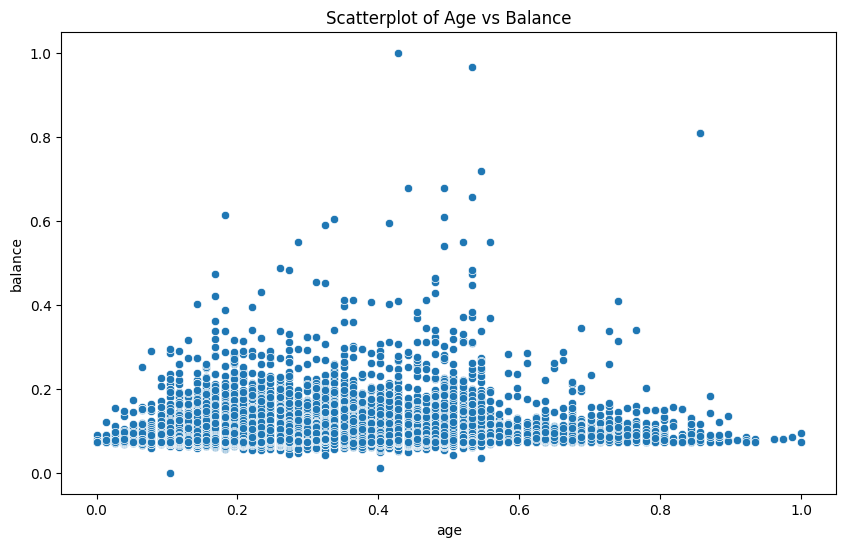

In [74]:
# Scatterplot between two continuous variables - using age vs balance as example
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='balance', data=bank_data)
plt.title('Scatterplot of Age vs Balance')
plt.savefig('scatterplot.png')  # Save the scatterplot image
plt.show()

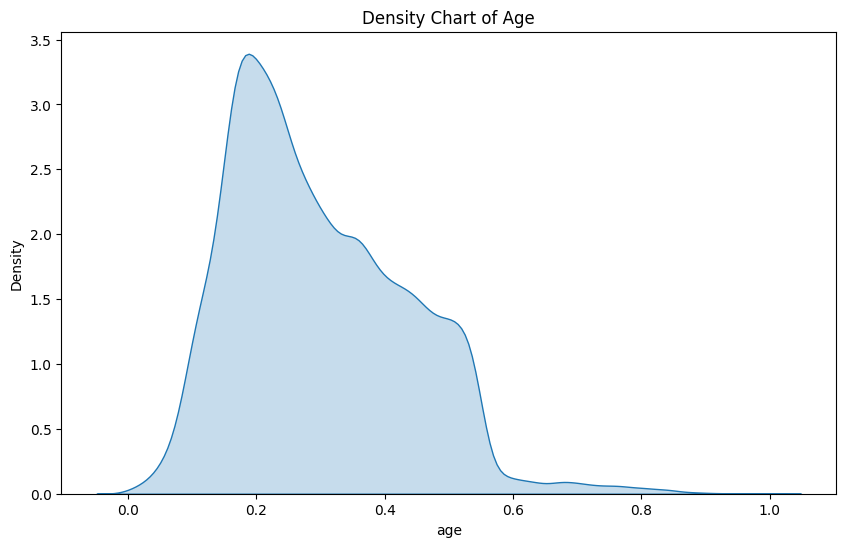

In [75]:
# Density chart of a continuous variable - using age as example
plt.figure(figsize=(10, 6))
sns.kdeplot(bank_data['age'], fill=True)
plt.title('Density Chart of Age')
plt.show()

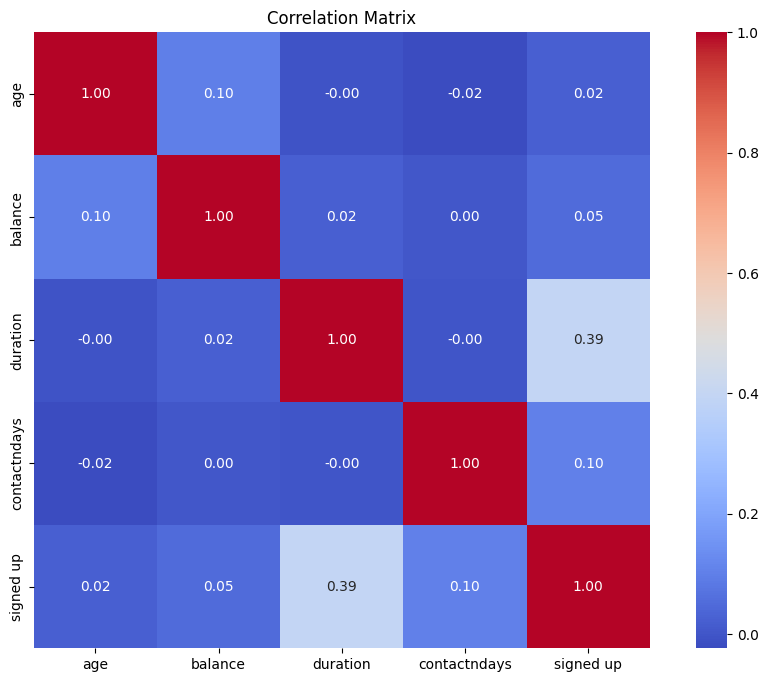

In [76]:
#Correlation matrix, make sure to only include numeric variables
num_values = bank_data.select_dtypes(include=['number'])
correlation_matrix = num_values.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()

## Analytics: Build a model and Tune it for best Best Performance

In [77]:
# What is the 'target' of a model and what is the prevalence of the target in your dataset? 
# Remember prevalence is the proportion of records that take on the value of interest for the target variable, usually the positive class.
target_prevalence = bank_data['signed up'].sum()
print(f'Target Prevalence: {target_prevalence}')
print(f'Total Records: {len(bank_data)}')
print(f'Prevalence Percentage: {target_prevalence / len(bank_data) * 100:.2f}%')

Target Prevalence: 5074.0
Total Records: 43628
Prevalence Percentage: 11.63%


In [78]:
# Divide the dataset into features and target
target = bank_data['signed up']  # Target variable
features = bank_data.drop(columns=['signed up']) # Drop the target column from features
print(f"Features shape: {features.shape}")
print(f"Target shape: {target.shape}")


Features shape: (43628, 28)
Target shape: (43628,)


In [79]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [80]:
# Include your table for the 10 values of k you tried and the corresponding accuracies.

accuracy_results = {}

# Test k values from 1 to 30, step by 3 (gives us ~10 values)
# This loop: creates a kNN classifier with k neighbors, trains it on the training data,
# scores it on the test data, and stores the result
for k in range(1, 31, 3):  
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train, y_train)
    accuracy = knn_model.score(X_test, y_test)
    accuracy_results[k] = accuracy
    print(f'k={k}: accuracy={accuracy:.4f}')

# Create a results dataframe
results_df = pd.DataFrame(list(accuracy_results.items()), columns=['k', 'Accuracy'])
print("\nAccuracy Results Table:")
print(results_df.to_string(index=False))

k=1: accuracy=0.8589
k=4: accuracy=0.8809
k=7: accuracy=0.8802
k=10: accuracy=0.8831
k=13: accuracy=0.8813
k=16: accuracy=0.8812
k=19: accuracy=0.8806
k=22: accuracy=0.8807
k=25: accuracy=0.8807
k=28: accuracy=0.8809

Accuracy Results Table:
 k  Accuracy
 1  0.858927
 4  0.880931
 7  0.880243
10  0.883108
13  0.881274
16  0.881160
19  0.880587
22  0.880701
25  0.880701
28  0.880931


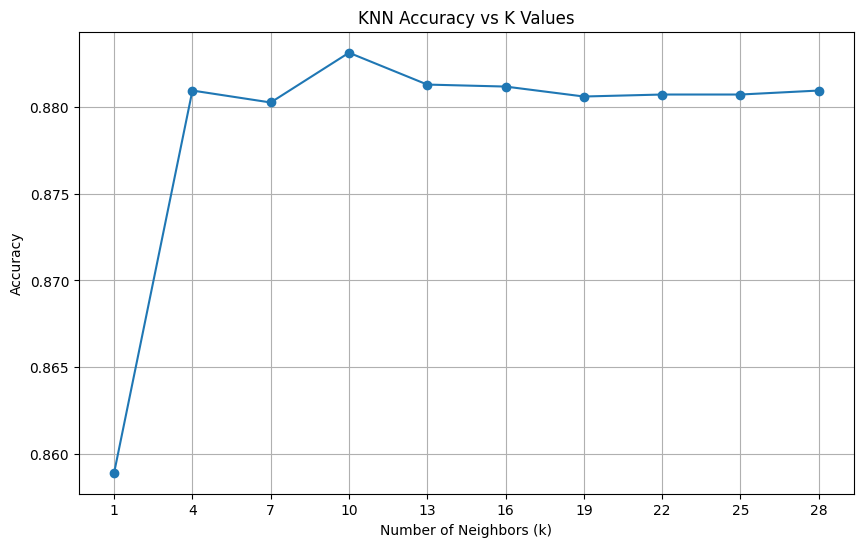

In [81]:
#graph of accuracy vs k values
plt.figure(figsize=(10, 6))
plt.plot(list(accuracy_results.keys()), list(accuracy_results.values()), marker='o')
plt.title('KNN Accuracy vs K Values')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(list(accuracy_results.keys()))
plt.grid()
plt.show()

In [ ]:
# using the hyperparameter k that gave the best accuracy, rerun the model and generate 
# predictions on the test set. Explain why you choose this k value.
best_k = max(accuracy_results, key=accuracy_results.get)  # Get the k with highest accuracy
print(f"Best k value: {best_k} with accuracy: {accuracy_results[best_k]:.4f}")

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)

Best k value: 10 with accuracy: 0.8831


## Value: Evaluation and Protected Classes

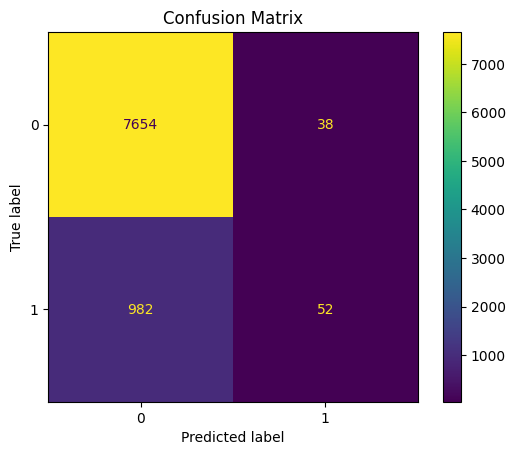

In [ ]:
# create a confusion matrix for your model's predictions. 
# What does the confusion matrix tell you about your model's performance?
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#We already have a model above using KNN so we can use the results to compute fairness metrics

# Compute fairness metrics using Fairlearn

my_metrics = {
    'true positive rate' : true_positive_rate,
    'false positive rate' : false_positive_rate,
    'selection rate' : selection_rate,
    'count' : count
}
# Construct a MetricFrame for race - find all race columns
race_cols = [col for col in X_test.columns if 'race_' in col or col == 'race']
gender_cols = [col for col in X_test.columns if 'gender_' in col or col == 'gender']

print(f"Race columns found: {race_cols}")
print(f"Gender columns found: {gender_cols}")

# Construct a MetricFrame for race (using first available race column)
if race_cols:
    mf_race = MetricFrame(
        metrics=my_metrics,
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=X_test[race_cols[0]]
    )

# Construct a MetricFrame for gender (using first available gender column)
if gender_cols:
    mf_gender = MetricFrame(
        metrics=my_metrics,
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=X_test[gender_cols[0]]
    )

Race columns found: ['race_black', 'race_hispanic', 'race_white']
Gender columns found: ['gender_m']


In [ ]:
mf_race.by_group #What do the results show? Change the mf_race with each subgroup and report the findings. This means
# you should run this cell multiple times, once for each of the levels in the race variable.

,true positive rate,false positive rate,selection rate,count
race_black,,,,
False,0.051122,0.005426,0.011051,6515.0
True,0.047414,0.003537,0.008141,2211.0


In [ ]:
mf_gender.by_group #What do the results show? There's only two groups here so we don't need to change anything. 
# in the metric frame.

,true positive rate,false positive rate,selection rate,count
gender_m,,,,
False,0.048649,0.005532,0.011032,4351.0
True,0.052192,0.004363,0.009600,4375.0


In [ ]:
# Derived fairness metrics. Be sure you understand the scale and meaning of these. Here we are calculating the 
# two fairness ratios using the gender_m feature, which is bi-variate. What do the results show, is the model more or 
# less fair with this grouping?

dpr_gender = fairlearn.metrics.demographic_parity_ratio(y_test, y_pred, sensitive_features=X_test['gender_m'])
print("Demographic Parity ratio:\t", dpr_gender)

eodds_gender = fairlearn.metrics.equalized_odds_ratio(y_test, y_pred, sensitive_features=X_test['gender_m'])
print("Equalized Odds ratio:\t\t", eodds_gender)

Demographic Parity ratio:	 0.8702
Equalized Odds ratio:		 0.7887454776571818


In [ ]:
# Derived fairness metrics. Be sure you understand the scale and meaning of these. Here we are calculating the 
# the same features above only using a filtered search to pull in all the possibilities of features
# starting with "race". What do the results show, is the model more or less fair with this grouping?

dpr_race = fairlearn.metrics.demographic_parity_ratio(y_test, y_pred, sensitive_features=X_test.filter(regex="race.*"))
print("Demographic Parity ratio:\t", dpr_race)

eodds_race = fairlearn.metrics.equalized_odds_ratio(y_test, y_pred, sensitive_features=X_test.filter(regex="race.*"))
print("Equalized Odds ratio:\t\t", eodds_race)

Demographic Parity ratio:	 0.6470676918438112
Equalized Odds ratio:		 0.3242221076156095


In [ ]:
#Optional code to add, commit, and push changes to your GitHub repository
!git add .
!git commit -m "Final Lab Completed" # This will commit your changes to git. 
!git push # This will push your changes to back to your remote repository on GitHub.

[main dfe877f] Final Lab Completed
 1 file changed, 21 insertions(+), 2 deletions(-)
Enumerating objects: 9, done.
Counting objects: 100% (9/9), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (5/5), 885 bytes | 885.00 KiB/s, done.
Total 5 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/rayandoraiswamy/ds1001_final
   acbf447..dfe877f  main -> main
